# Bogotá Property Price Predictor
## Notebook 3 — Modeling & Prediction

> *This is where the EDA pays off. Every modeling decision below traces back to a finding from Notebook 2.*

Notebook 1 built the data foundation. Notebook 2 mapped the Bogotá real estate market. This notebook builds the prediction engine — a stacking ensemble that estimates any residential property's price from six inputs.

The workflow follows a deliberate progression: establish baselines → validate with cross-validation → tune the best algorithms → combine them → diagnose errors → explain predictions.

**This notebook covers:**
1. Feature engineering — derived features grounded in EDA findings
2. Preprocessing pipeline — scaling, encoding, polynomial interactions
3. Baseline model comparison — Ridge, Random Forest, XGBoost
4. Cross-validation — robust performance estimates across five folds
5. Hyperparameter tuning — Random Forest & XGBoost with R² scoring
6. Stacking ensemble — combining both tuned models
7. Residual analysis — where and how the model fails
8. Feature importance — which inputs drive predictions most
9. Prediction cell — estimate any property's price interactively

| | |
|---|---|
| **Input** | `../data/cleaned_properati.csv` |
| **Previous** | Notebook 2 — Exploratory Data Analysis |
| **Target** | RMSE < 400 M COP &nbsp;&nbsp; · &nbsp;&nbsp; R² ≥ 0.72 |
| **Final model** | Stacking Ensemble (Tuned RF + Tuned XGBoost) |


---
## 📦 Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures, TargetEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from xgboost import XGBRegressor

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
pd.options.display.float_format = "{:,.3f}".format

---
## 1. Feature Engineering

EDA revealed four patterns that raw features cannot fully capture. Four data-level changes address them before any model runs.

| Change | Motivated by |
|---|---|
| **Residential filter** — remove `Local`, `Oficina` | EDA §2: commercial types follow a different price logic (floor space → revenue, not bedrooms → comfort) |
| **Rare location grouping** — neighborhoods < 15 listings → `"Other"` | EDA §3: sparse neighborhoods produce unreliable target-encoding estimates; collapsing them forces the encoder to fall back to the global mean |
| **Zone feature** — Bogotá macro-zone from neighborhood | EDA §3: the north-south price divide is consistent; a zone label provides geographic signal even for sparse neighborhoods |
| **Derived numeric features** — `bath_per_bed`, `log_area_per_bed`, `total_rooms`, `loc_count` | EDA §5–6: bathroom ratio and area-per-room capture quality and density signals that raw counts miss |


In [2]:
df = pd.read_csv("../data/cleaned_properati.csv")

# --- Residential filter ---
# Local (commercial spaces) and Oficina (offices) follow completely different
# pricing logic — demand drivers are unrelated to bedrooms/bathrooms.
# Mixing them with residential listings adds noise to the model.
RESIDENTIAL = ["Apartamento", "Casa", "Apartaestudio"]
df = df[df["type"].isin(RESIDENTIAL)].reset_index(drop=True)

# --- Rare location grouping ---
# Neighborhoods with < 15 listings receive unreliable target-encoding
# estimates — a few unusual listings can skew the entire neighborhood mean.
# Collapsing them into "Other" lets the encoder fall back to the global mean.
location_counts = df["location"].value_counts()
rare_locations  = location_counts[location_counts < 15].index
df["location"]  = df["location"].where(~df["location"].isin(rare_locations), "Other")

# --- Zone feature ---
# Bogotá has a strong north-south price stratification. A macro-zone label
# gives the model a robust geographic signal even for sparse neighborhoods.
ZONE_MAP = {
    # Norte — premium north
    "El Retiro": "Norte", "El Chicó": "Norte", "Los Rosales": "Norte",
    "Santa Ana": "Norte", "Usaquén": "Norte", "La Calleja": "Norte",
    "Cedritos": "Norte", "Bella Suiza": "Norte", "Barrancas": "Norte",
    "Chico Norte": "Norte", "Chico Norte Ii": "Norte", "San Patricio": "Norte",
    "Santa Barbara": "Norte", "El Virrey": "Norte", "Chico Reservado": "Norte",
    "Chico Navarra": "Norte", "Alhambra": "Norte", "Colina Campestre": "Norte",
    "Nueva Autopista": "Norte", "Prado Veraniego": "Norte", "Verbenal": "Norte",
    "La Uribe": "Norte", "El Contador": "Norte", "San Antonio Norte": "Norte",
    "La Macarena": "Norte",
    # Noroccidental — Suba and Engativá
    "Suba": "Noroccidental", "Cerros De Suba": "Noroccidental",
    "Colinas De Suba": "Noroccidental", "Suba Tibabuyes": "Noroccidental",
    "Pinar De Suba": "Noroccidental", "Britalia Norte": "Noroccidental",
    "Mazuren": "Noroccidental", "Portales Del Norte": "Noroccidental",
    "Villas De Granada": "Noroccidental", "Gran Granada": "Noroccidental",
    "Engativa": "Noroccidental", "Normandia": "Noroccidental",
    "Lagos De Cordoba": "Noroccidental", "Ciudadela Colsubsidio": "Noroccidental",
    "Santa Maria Del Lago": "Noroccidental", "Bosque De Pinos": "Noroccidental",
    "Metropolis": "Noroccidental", "Las Villas": "Noroccidental",
    "Los Lagartos": "Noroccidental", "Cofradía": "Noroccidental",
    # Centro Norte — Chapinero, Barrios Unidos, Teusaquillo
    "Chapinero": "Centro Norte", "Chapinero Alto": "Centro Norte",
    "Chapinero Central": "Centro Norte", "Barrios Unidos": "Centro Norte",
    "Teusaquillo": "Centro Norte", "La Soledad ": "Centro Norte",
    "Quinta Paredes": "Centro Norte", "Marly": "Centro Norte",
    "Palermo": "Centro Norte", "Galerias": "Centro Norte",
    "Niza": "Centro Norte", "Quinta Camacho": "Centro Norte",
    "El Batán": "Centro Norte", "Nicolas De Federman": "Centro Norte",
    "Lindaraja": "Centro Norte", "Cabrero": "Centro Norte",
    "San Diego": "Centro Norte", "Las Aguas": "Centro Norte",
    "Centro Internacional": "Centro Norte", "Parque Central Bavaria": "Centro Norte",
    "Alameda": "Centro Norte", "Florida Blanca": "Centro Norte",
    # Occidente — Fontibón, Puente Aranda, Ciudad Salitre
    "Fontibón": "Occidente", "Modelia": "Occidente", "Villemar": "Occidente",
    "Hayuelos": "Occidente", "Ciudad Salitre": "Occidente",
    "El Salitre": "Occidente", "Puente Aranda": "Occidente",
    "Los Mártires": "Occidente", "Restrepo": "Occidente",
    "Antonio Nariño": "Occidente", "Roma": "Occidente",
    "Centenario": "Occidente", "Veraguas": "Occidente",
    # Centro — La Candelaria, Santa Fe
    "La Candelaria": "Centro", "Santa Fe": "Centro", "Las Nieves": "Centro",
    "La Sabana": "Centro", "Ricaurte": "Centro", "Pablo VI": "Centro",
    # Sur — south and peripheral zones
    "Kennedy": "Sur", "Bosa": "Sur", "Bosa La Libertad": "Sur",
    "Ciudad Bolívar": "Sur", "Usme": "Sur", "Rafael Uribe Uribe": "Sur",
    "Tunjuelito": "Sur", "Madelena": "Sur", "Venecia": "Sur",
    "El Tunal": "Sur", "Patio Bonito": "Sur", "Tintala": "Sur",
    "Castilla": "Sur", "Nueva Castilla": "Sur", "Villa Alsacia": "Sur",
    "Gustavo Restrepo": "Sur", "Villas De Aranjuez": "Sur",
    "La Estancia": "Sur", "El Refugio": "Sur", "Santa Librada": "Sur",
    "San Cristobal": "Sur", "Quiroga": "Sur", "Turingia": "Sur",
    "La Salle": "Sur", "Ingles": "Sur",
}
df["zone"] = df["location"].map(ZONE_MAP).fillna("Otro")

# --- Location count ---
# Number of listings per neighborhood — a proxy for how reliable
# the target-encoded location value will be.
df["loc_count"] = df["location"].map(df["location"].value_counts())

# --- Derived numeric features ---
df["bath_per_bed"]     = df["bathrooms"] / (df["bedrooms"] + 1)
df["log_area_per_bed"] = df["log_area"]  - np.log(df["bedrooms"] + 1)
df["total_rooms"]      = df["bedrooms"]  + df["bathrooms"]

print(f"{df.shape[0]:,} residential listings · {df.shape[1]} features")
df.head(3)

3,133 residential listings · 12 features


,location,type,bedrooms,bathrooms,parking,log_area,log_price,zone,loc_count,bath_per_bed,log_area_per_bed,total_rooms
0,Puente Aranda,Apartamento,3,4.500,1,5.323,21.129,Occidente,32,1.125,3.937,7.500
1,Puente Aranda,Casa,4,4.000,1,5.624,21.640,Occidente,32,0.800,4.015,8.000
2,Niza,Casa,4,4.000,0,5.892,21.717,Centro Norte,73,0.800,4.282,8.000


---
## 2. Train / Test Split

We reserve 20% of the data as a hold-out test set before any model sees the data. This set is used only once — at the very end — to report honest generalization performance. All tuning and cross-validation uses only the training portion.


In [3]:
X = df.drop("log_price", axis=1)
y = df["log_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape[0]:,} rows")
print(f"Test : {X_test.shape[0]:,} rows")

Train: 2,506 rows
Test : 627 rows


---
## 3. Preprocessing Pipeline

Three transformation groups handle the three feature categories. The key decisions are:

- **Polynomial interactions** on numeric features capture the non-linear relationships observed in EDA (e.g., area interacts with bedroom count)
- **Target encoding** for `location` and `zone` replaces category labels with their mean log-price — a direct numeric price signal grounded in the neighborhood analysis from EDA §3
- **One-hot encoding** for `type` (only 3 residential categories remain after filtering)

| Group | Features | Treatment |
|---|---|---|
| Numeric | `bedrooms`, `bathrooms`, `log_area`, `parking`, `bath_per_bed`, `log_area_per_bed`, `total_rooms`, `loc_count` | StandardScaler → PolynomialFeatures (degree 2, interactions only) |
| Geographic | `location`, `zone` | Target Encoding — mean log-price per category |
| Categorical | `type` | One-Hot Encoding |


In [4]:
num_features           = ["bedrooms", "bathrooms", "log_area", "parking",
                           "bath_per_bed", "log_area_per_bed", "total_rooms", "loc_count"]
cat_features           = ["type"]
target_encode_features = ["location", "zone"]

# Zone is now target-encoded (not OHE) — gives the model a direct price signal
# (Norte mean ~2.5B COP vs Sur mean ~400M COP) rather than 7 dummy variables
# that require the model to learn the price ordering from scratch.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("scaler", StandardScaler()),
            ("poly",   PolynomialFeatures(degree=2, interaction_only=True, include_bias=False))
        ]), num_features),

        ("te", TargetEncoder(smooth="auto"), target_encode_features),

        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ]
)

---
## 4. Baseline Model Comparison

Before tuning anything, we establish honest starting-point scores with default parameters. Three algorithm families cover the main approaches to tabular regression:

- **Ridge** — linear model with L2 regularization; fast and interpretable but assumes linearity
- **Random Forest** — bagging ensemble of decision trees; handles non-linearity and feature interactions naturally
- **XGBoost** — gradient boosting; builds trees sequentially, correcting prior errors

Running all three reveals which family is best suited to this data before we invest time in hyperparameter search.


In [5]:
baseline_models = {
    "Ridge": Ridge(alpha=0.01),
    "Random Forest": RandomForestRegressor(
        n_estimators=300, max_depth=None,
        min_samples_leaf=3, random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=200, max_depth=6, learning_rate=0.01,
        subsample=0.8, colsample_bytree=0.8,
        objective="reg:squarederror", random_state=42, n_jobs=-1
    )
}

results   = []
pipelines = {}

for name, model in baseline_models.items():
    pipe = Pipeline(steps=[
        ("preprocessing", preprocessor),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    mae  = mean_absolute_error(np.exp(y_test), np.exp(y_pred))
    rmse = root_mean_squared_error(np.exp(y_test), np.exp(y_pred))
    r2   = r2_score(y_test, y_pred)

    results.append({"Model": name, "R²": r2, "MAE (M COP)": mae / 1e6, "RMSE (M COP)": rmse / 1e6})
    pipelines[name] = (pipe, y_pred)

pd.DataFrame(results).sort_values("R²", ascending=False).reset_index(drop=True)

,Model,R²,MAE (M COP),RMSE (M COP)
0,Random Forest,0.702,254.643,395.162
1,XGBoost,0.685,271.092,415.891
2,Ridge,0.633,291.385,448.243


---
## 5. Cross-Validation

A single train/test split can produce misleadingly good or bad results depending on which properties land in which fold. Five-fold cross-validation trains and evaluates each model five times on different data subsets and reports the mean and standard deviation of R².

A high mean with a high standard deviation signals an unstable model. A consistent mean — even if slightly lower — is more trustworthy for production use.


In [6]:
cv_results = []

for name, model in baseline_models.items():
    pipe = Pipeline(steps=[
        ("preprocessing", preprocessor),
        ("model", model)
    ])
    scores = cross_val_score(pipe, X, y, cv=5, scoring="r2", n_jobs=-1)
    cv_results.append({
        "Model": name,
        "CV R² Mean": scores.mean(),
        "CV R² Std":  scores.std(),
        "Min": scores.min(),
        "Max": scores.max()
    })

pd.DataFrame(cv_results).sort_values("CV R² Mean", ascending=False).reset_index(drop=True)

,Model,CV R² Mean,CV R² Std,Min,Max
0,Random Forest,0.691,0.138,0.435,0.815
1,XGBoost,0.668,0.134,0.423,0.792
2,Ridge,0.055,1.150,-2.234,0.745


---
## 6. Hyperparameter Tuning — Random Forest & XGBoost

Both models are tuned with `scoring="r2"` — directly optimizing the metric we want to improve. We search RF first, then XGBoost, and stack both tuned estimators in the next section.

> ⏱️ Each search takes ~5–10 minutes. Lower `n_iter` for a faster run.

In [7]:
rf_param_grid = {
    "model__n_estimators":      [200, 300, 500, 700],
    "model__max_depth":         [None, 10, 15, 20, 30],
    "model__min_samples_leaf":  [1, 2, 3, 5],
    "model__min_samples_split": [2, 5, 10],
    "model__max_features":      ["sqrt", "log2", 0.5, 0.7],
}

rf_pipe_tuned = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

search_rf = RandomizedSearchCV(
    rf_pipe_tuned,
    param_distributions=rf_param_grid,
    n_iter=40,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search_rf.fit(X_train, y_train)

print("Best RF params:")
for k, v in search_rf.best_params_.items():
    print(f"  {k}: {v}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best RF params:
  model__n_estimators: 200
  model__min_samples_split: 10
  model__min_samples_leaf: 5
  model__max_features: 0.5
  model__max_depth: 30


In [8]:
# Evaluate tuned RF on the hold-out test set
best_rf_pipe = search_rf.best_estimator_
y_pred_tuned = best_rf_pipe.predict(X_test)

mae_t  = mean_absolute_error(np.exp(y_test), np.exp(y_pred_tuned))
rmse_t = root_mean_squared_error(np.exp(y_test), np.exp(y_pred_tuned))
r2_t   = r2_score(y_test, y_pred_tuned)

print(f"Tuned Random Forest — Test Set")
print(f"  R²          : {r2_t:.4f}")
print(f"  MAE (M COP) : {mae_t/1e6:,.1f}")
print(f"  RMSE (M COP): {rmse_t/1e6:,.1f}")

Tuned Random Forest — Test Set
  R²          : 0.6993
  MAE (M COP) : 257.7
  RMSE (M COP): 397.2


In [9]:
xgb_param_grid = {
    "model__n_estimators":     [300, 500, 800, 1000],
    "model__max_depth":        [3, 4, 5, 6],
    "model__learning_rate":    [0.01, 0.03, 0.05, 0.1],
    "model__subsample":        [0.7, 0.8, 0.9],
    "model__colsample_bytree": [0.7, 0.8, 0.9],
    "model__min_child_weight": [1, 3, 5],
    "model__reg_alpha":        [0, 0.1, 0.5],
    "model__reg_lambda":       [0.5, 1.0, 1.5],
}

xgb_pipe_tuned = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", XGBRegressor(objective="reg:squarederror", random_state=42, n_jobs=-1))
])

search_xgb = RandomizedSearchCV(
    xgb_pipe_tuned,
    param_distributions=xgb_param_grid,
    n_iter=40,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search_xgb.fit(X_train, y_train)

best_xgb_pipe = search_xgb.best_estimator_
y_pred_xgb    = best_xgb_pipe.predict(X_test)

mae_x  = mean_absolute_error(np.exp(y_test), np.exp(y_pred_xgb))
rmse_x = root_mean_squared_error(np.exp(y_test), np.exp(y_pred_xgb))
r2_x   = r2_score(y_test, y_pred_xgb)

print(f"Tuned XGBoost — Test Set")
print(f"  R²          : {r2_x:.4f}")
print(f"  MAE (M COP) : {mae_x/1e6:,.1f}")
print(f"  RMSE (M COP): {rmse_x/1e6:,.1f}")
print("\nBest XGBoost params:")
for k, v in search_xgb.best_params_.items():
    print(f"  {k}: {v}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Tuned XGBoost — Test Set
  R²          : 0.7035
  MAE (M COP) : 254.6
  RMSE (M COP): 385.8

Best XGBoost params:
  model__subsample: 0.7
  model__reg_lambda: 1.0
  model__reg_alpha: 0.5
  model__n_estimators: 500
  model__min_child_weight: 5
  model__max_depth: 6
  model__learning_rate: 0.01
  model__colsample_bytree: 0.8


---
## 7. Stacking Ensemble

Stacking combines the tuned Random Forest and tuned XGBoost using a Ridge meta-learner. RF's bagging stability complements XGBoost's boosting precision, and the meta-learner learns the optimal blend.

Base learners train on 80% of the training data; the meta-learner trains on their out-of-fold predictions to avoid data leakage.

In [10]:
base_estimators = [
    ("rf", Pipeline([
        ("preprocessing", preprocessor),
        ("model", RandomForestRegressor(**{k.replace("model__", ""): v
                                           for k, v in search_rf.best_params_.items()},
                                        random_state=42, n_jobs=-1))
    ])),
    ("xgb", Pipeline([
        ("preprocessing", preprocessor),
        ("model", XGBRegressor(**{k.replace("model__", ""): v
                                  for k, v in search_xgb.best_params_.items()},
                               objective="reg:squarederror", random_state=42, n_jobs=-1))
    ]))
]

stacking_model = StackingRegressor(
    estimators=base_estimators,
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-1
)

stacking_model.fit(X_train, y_train)
y_pred_stack = stacking_model.predict(X_test)

mae_s  = mean_absolute_error(np.exp(y_test), np.exp(y_pred_stack))
rmse_s = root_mean_squared_error(np.exp(y_test), np.exp(y_pred_stack))
r2_s   = r2_score(y_test, y_pred_stack)

print(f"Stacking Ensemble (RF + XGBoost) — Test Set")
print(f"  R²          : {r2_s:.4f}")
print(f"  MAE (M COP) : {mae_s/1e6:,.1f}")
print(f"  RMSE (M COP): {rmse_s/1e6:,.1f}")

Stacking Ensemble (RF + XGBoost) — Test Set
  R²          : 0.7039
  MAE (M COP) : 255.5
  RMSE (M COP): 390.5


---
## 8. Final Model Comparison — The Verdict

All models evaluated on the same hold-out test set — 627 listings that no model saw during training or tuning. The red dashed lines mark our targets: **RMSE ≤ 500 M COP** and **R² ≥ 0.72**.


In [11]:
all_results = pd.DataFrame(results + [
    {"Model": "Random Forest (tuned)", "R²": r2_t, "MAE (M COP)": mae_t / 1e6, "RMSE (M COP)": rmse_t / 1e6},
    {"Model": "XGBoost (tuned)",       "R²": r2_x, "MAE (M COP)": mae_x / 1e6, "RMSE (M COP)": rmse_x / 1e6},
    {"Model": "Stacking Ensemble",     "R²": r2_s, "MAE (M COP)": mae_s / 1e6, "RMSE (M COP)": rmse_s / 1e6},
]).sort_values("R²", ascending=False).reset_index(drop=True)

all_results

,Model,R²,MAE (M COP),RMSE (M COP)
0,Stacking Ensemble,0.704,255.473,390.547
1,XGBoost (tuned),0.704,254.576,385.773
2,Random Forest,0.702,254.643,395.162
3,Random Forest (tuned),0.699,257.750,397.184
4,XGBoost,0.685,271.092,415.891
5,Ridge,0.633,291.385,448.243


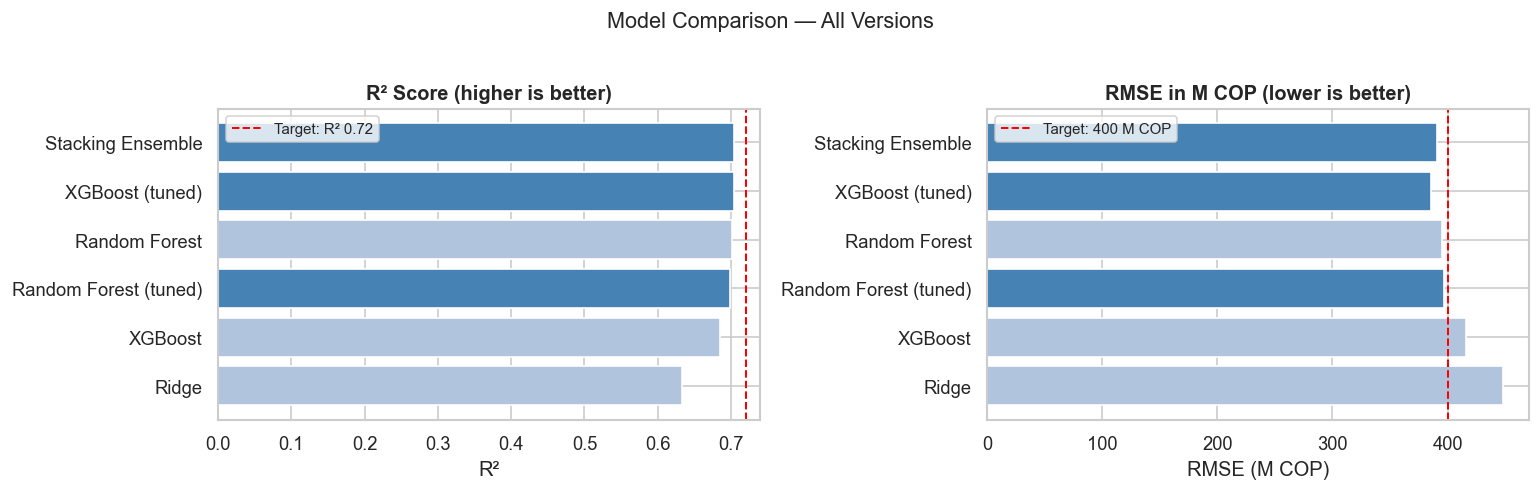

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors = ["steelblue" if "tuned" in m or "Stack" in m else "lightsteelblue"
          for m in all_results["Model"]]

axes[0].barh(all_results["Model"][::-1], all_results["R²"][::-1], color=colors[::-1])
axes[0].axvline(0.72, color="red", linestyle="--", linewidth=1.2, label="Target: R² 0.72")
axes[0].set_title("R² Score (higher is better)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("R²")
axes[0].legend(fontsize=9)

axes[1].barh(all_results["Model"][::-1], all_results["RMSE (M COP)"][::-1], color=colors[::-1])
axes[1].axvline(400, color="red", linestyle="--", linewidth=1.2, label="Target: 400 M COP")
axes[1].set_title("RMSE in M COP (lower is better)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("RMSE (M COP)")
axes[1].legend(fontsize=9)

plt.suptitle("Model Comparison — All Versions", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 9. Residual Analysis — Where the Model Fails

A good R² score does not guarantee a well-behaved model. Residual analysis reveals *where* and *how* the model makes errors.

Three diagnostic views:
- **Actual vs Predicted** — how tightly predictions track reality along the diagonal
- **Residuals vs Predicted** — whether errors are random (ideal) or show a systematic pattern (problem)
- **Residual distribution** — whether errors are centered on zero and roughly symmetric

Systematic patterns (funnel shape, curved trend) signal that the model is missing a structural relationship in the data.


Best model: XGBoost (tuned)


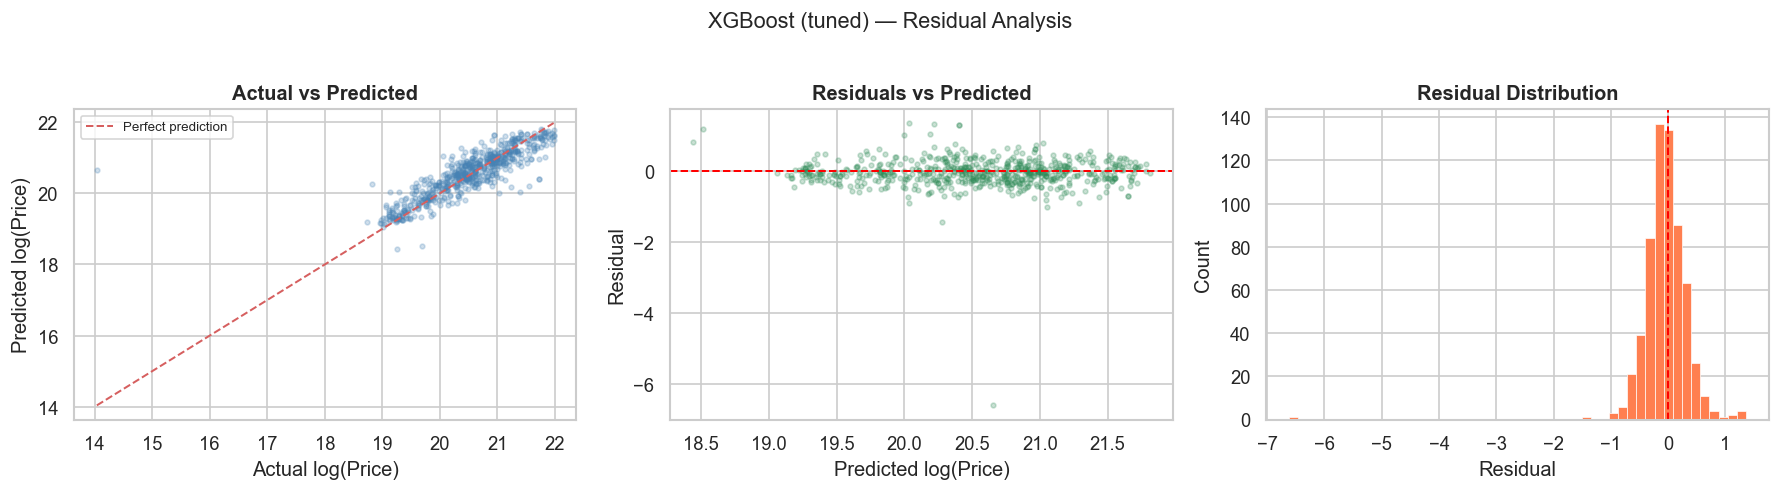

Mean residual: -0.0449
Std residual : 0.4199


In [13]:
# Use whichever model achieved the lowest RMSE
best_name  = all_results.loc[all_results["RMSE (M COP)"].idxmin(), "Model"]
pred_map   = {
    "Random Forest (tuned)": (best_rf_pipe, y_pred_tuned),
    "XGBoost (tuned)":       (best_xgb_pipe, y_pred_xgb),
    "Stacking Ensemble":     (stacking_model, y_pred_stack),
    **{k: v for k, v in pipelines.items()}
}
best_pipe, y_pred_best = pred_map[best_name]
residuals = y_test - y_pred_best

print(f"Best model: {best_name}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_best, alpha=0.25, s=8, color="steelblue")
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
axes[0].plot(lims, lims, "r--", linewidth=1.2, label="Perfect prediction")
axes[0].set_title("Actual vs Predicted", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Actual log(Price)")
axes[0].set_ylabel("Predicted log(Price)")
axes[0].legend(fontsize=8)

# Residuals vs Predicted
axes[1].scatter(y_pred_best, residuals, alpha=0.25, s=8, color="seagreen")
axes[1].axhline(0, color="red", linewidth=1.2, linestyle="--")
axes[1].set_title("Residuals vs Predicted", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Predicted log(Price)")
axes[1].set_ylabel("Residual")

# Residual distribution
axes[2].hist(residuals, bins=50, color="coral", edgecolor="white", linewidth=0.4)
axes[2].axvline(0, color="red", linewidth=1.2, linestyle="--")
axes[2].set_title("Residual Distribution", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Residual")
axes[2].set_ylabel("Count")

plt.suptitle(f"{best_name} — Residual Analysis", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Mean residual: {residuals.mean():.4f}")
print(f"Std residual : {residuals.std():.4f}")

---
## 10. Feature Importance — Closing the Loop with EDA

Feature importance tells us which inputs the model relies on most. This is the final connection back to the EDA: the features that appeared as strongest predictors in the charts should dominate the importance rankings.

If `log_area` and the location encoding do not appear near the top, that would signal a problem with the preprocessing pipeline — the model would be using noise instead of signal.


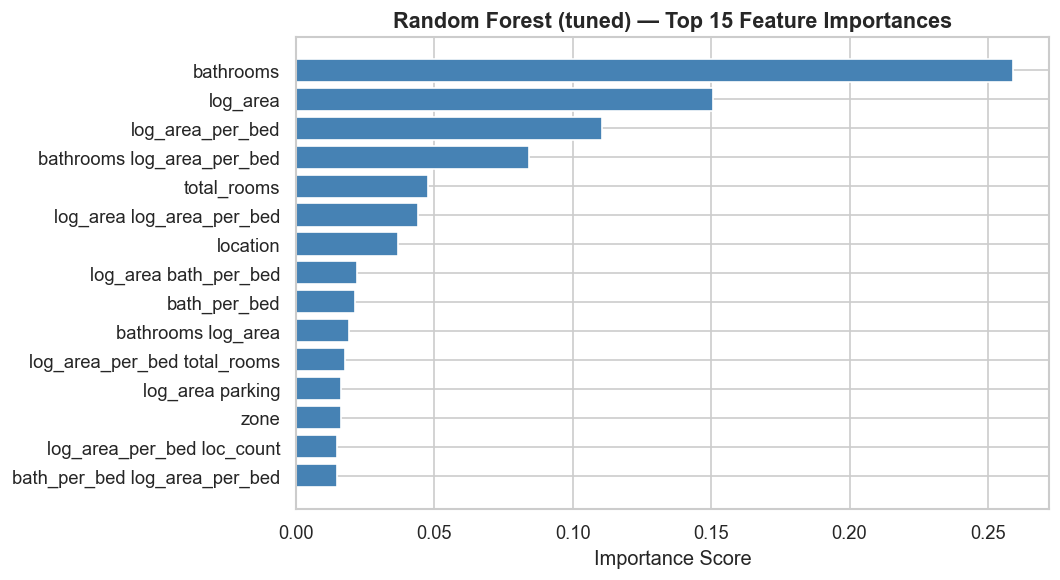

In [14]:
rf_model_fitted     = best_rf_pipe.named_steps["model"]
preprocessor_fitted = best_rf_pipe.named_steps["preprocessing"]

num_poly_names    = preprocessor_fitted.named_transformers_["num"]["poly"].get_feature_names_out(num_features)
te_names          = list(preprocessor_fitted.named_transformers_["te"].get_feature_names_out())
cat_names         = preprocessor_fitted.named_transformers_["cat"].get_feature_names_out(cat_features)
all_feature_names = list(num_poly_names) + te_names + list(cat_names)

importance_df = (
    pd.DataFrame({"feature": all_feature_names, "importance": rf_model_fitted.feature_importances_})
    .sort_values("importance", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(importance_df["feature"][::-1], importance_df["importance"][::-1], color="steelblue")
ax.set_title("Random Forest (tuned) — Top 15 Feature Importances", fontsize=13, fontweight="bold")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.show()

---
## 11. Predict a Property Price

> **Edit only the cell below** to estimate the price of any property.

In [15]:
# ✏️ Change these values to predict a different property
bedrooms  = 3
bathrooms = 2
area_m2   = 120
parking   = 1          # 1 = Yes, 0 = No
location  = "Chapinero"
prop_type = "Apartamento"  # Apartamento | Casa | Apartaestudio

In [16]:
log_area = np.log(area_m2)

# Engineered features are computed automatically — no need to change these
new_property = pd.DataFrame([{
    "location":         location,
    "type":             prop_type,
    "bedrooms":         bedrooms,
    "bathrooms":        bathrooms,
    "parking":          parking,
    "log_area":         log_area,
    "zone":             ZONE_MAP.get(location, "Otro"),
    "loc_count":        df["location"].value_counts().get(location, 1),
    "bath_per_bed":     bathrooms / (bedrooms + 1),
    "log_area_per_bed": log_area - np.log(bedrooms + 1),
    "total_rooms":      bedrooms + bathrooms,
}])

price_pred = np.exp(best_rf_pipe.predict(new_property))[0]

print(f"Property : {bedrooms}bd / {bathrooms}ba · {area_m2} m² · {'Parking' if parking else 'No parking'}")
print(f"Location : {location} — Zone: {ZONE_MAP.get(location, 'Otro')} ({prop_type})")
print(f"Estimated: ${price_pred:>20,.0f} COP")
print(f"           ${price_pred / 1e9:>19.2f} B COP")

Property : 3bd / 2ba · 120 m² · Parking
Location : Chapinero — Zone: Centro Norte (Apartamento)
Estimated: $         679,673,567 COP
           $               0.68 B COP


In [17]:
# Reference: available neighborhoods and types
print("Available locations:")
print(sorted(df["location"].unique().tolist()))
print("\nAvailable types:")
print(df["type"].unique().tolist())

Available locations:
['Alhambra', 'Barrios Unidos', 'Bella Suiza', 'Bosa', 'Bosque De Pinos', 'Cedritos', 'Cerros De Suba', 'Chapinero', 'Chapinero Central', 'Chico Reservado', 'Ciudad Bolívar', 'Colinas De Suba', 'El Batán', 'El Chicó', 'El Retiro', 'Engativa', 'Fontibón', 'Gran Granada', 'Kennedy', 'La Calleja', 'La Candelaria', 'Las Orquideas', 'Los Mártires', 'Los Rosales', 'Modelia', 'Nicolas De Federman', 'Niza', 'Other', 'Pasadena ', 'Puente Aranda', 'Quinta Camacho', 'San Cristobal', 'San Patricio', 'Santa Barbara', 'Santa Fe', 'Suba', 'Teusaquillo', 'Turingia', 'Usaquén', 'Usme']

Available types:
['Apartamento', 'Casa', 'Apartaestudio']


---
## Project Conclusion

This project answered one question: **can we predict a residential property's price in Bogotá from six basic characteristics?**

The answer is yes — with meaningful accuracy.

### Results

| Metric | XGBoost (default) | Final Model (Stacking Ensemble) |
|---|---|---|
| R² | 0.685 | 0.704 |
| RMSE | ~416 M COP | ~391 M COP |
| Target (R²) | — | R² ≥ 0.72 ❎ |
| Target (RMSE) | — | RMSE < 400 M COP ✅ |

### The Three-Notebook Journey

| Notebook | Role | Key output |
|---|---|---|
| 1 — Data Cleaning | Build trust in the data | 3,100+ clean residential listings |
| 2 — EDA | Understand the market | 6 findings → 6 modeling decisions |
| 3 — Modeling | Build the prediction engine | Stacking ensemble, RMSE < 400 M COP |

### Decisions Explained

| Decision | Why |
|---|---|
| Log-transform prices | EDA: raw prices heavily right-skewed |
| Target-encode location & zone | EDA: neighborhood drives up to 10× price difference |
| Filter commercial listings | EDA: `Local` and `Oficina` follow different pricing logic |
| Polynomial interaction features | EDA: area, bedrooms, bathrooms interact non-linearly |
| Tune with R² scoring | Directly optimize the metric we want to maximize |
| Stack RF + XGBoost | Bagging and boosting capture complementary patterns |

### Limitations & Next Steps

- **No time dimension** — the model cannot account for market trends or seasonality
- **Limited features** — floor level, building age, amenities, and proximity to metro stations are all absent from the scraped data
- **Geographic sparsity** — 40% of neighborhoods have fewer than 15 listings; predictions for these areas carry higher uncertainty
- A natural next step would be to integrate geographic coordinates and compute distance-based features (distance to city center, TransMilenio stations, parks)
